<a href="https://colab.research.google.com/github/asiddiqha/ML_Practice/blob/main/HousePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error,
    explained_variance_score,
    max_error,
    r2_score
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression

# House Price Prediction using Machine Learning

## Problem Statement

The objective of this project is to predict house prices based on various property characteristics such as area, number of bedrooms, bathrooms, parking spaces, furnishing status, and other amenities.

The project follows a complete machine learning workflow including data preprocessing, exploratory data analysis (EDA), feature engineering, model training, evaluation, and prediction using regression algorithms.

In [ ]:
df = pd.read_csv('linear_sample.csv')

In [ ]:
df.head()

,House_ID,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City (km),Parking,Floor,Nearby_Schools,Crime_Rate,House_Price (₹ Lakhs)
0,H001,800,2,1,15,12,1,1,2,4,42
1,H002,950,2,2,10,10,1,2,3,3,50
2,H003,1100,3,2,8,8,1,3,4,2,60
3,H004,1250,3,2,6,7,1,4,5,2,68
4,H005,1400,3,3,5,6,2,5,5,1,78


In [ ]:
df.describe()

,Area_sqft,Bedrooms,Bathrooms,Age_of_House,Distance_to_City (km),Parking,Floor,Nearby_Schools,Crime_Rate,House_Price (₹ Lakhs)
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,1578.333333,3.600000,2.966667,5.800000,6.033333,1.633333,5.666667,4.433333,1.866667,89.866667
std,490.018179,1.037238,1.066200,4.566746,3.681111,0.490133,2.795727,0.935261,1.166585,32.218792
min,800.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,40.000000
25%,1162.500000,3.000000,2.000000,2.000000,3.000000,1.000000,3.250000,4.000000,1.000000,63.000000
50%,1575.000000,4.000000,3.000000,4.500000,5.000000,2.000000,6.000000,5.000000,1.000000,89.000000
75%,1937.500000,4.000000,4.000000,8.000000,8.000000,2.000000,8.000000,5.000000,2.000000,115.000000
max,2500.000000,5.000000,5.000000,18.000000,15.000000,2.000000,10.000000,5.000000,5.000000,150.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   House_ID               30 non-null     object
 1   Area_sqft              30 non-null     int64 
 2   Bedrooms               30 non-null     int64 
 3   Bathrooms              30 non-null     int64 
 4   Age_of_House           30 non-null     int64 
 5   Distance_to_City (km)  30 non-null     int64 
 6   Parking                30 non-null     int64 
 7   Floor                  30 non-null     int64 
 8   Nearby_Schools         30 non-null     int64 
 9   Crime_Rate             30 non-null     int64 
 10  House_Price (₹ Lakhs)  30 non-null     int64 
dtypes: int64(10), object(1)
memory usage: 2.7+ KB


In [ ]:
df.shape

(30, 11)

In [ ]:
df.isnull().sum()

,0
House_ID,0
Area_sqft,0
Bedrooms,0
Bathrooms,0
Age_of_House,0
Distance_to_City (km),0
Parking,0
Floor,0
Nearby_Schools,0
Crime_Rate,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop('House_ID', axis=1)

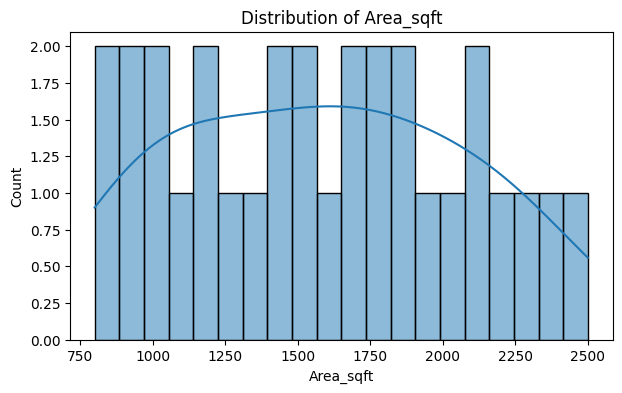

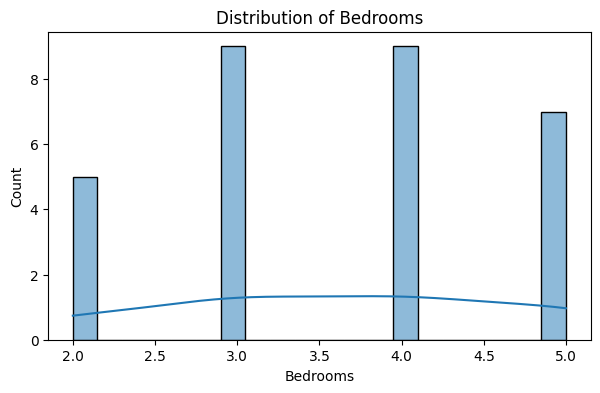

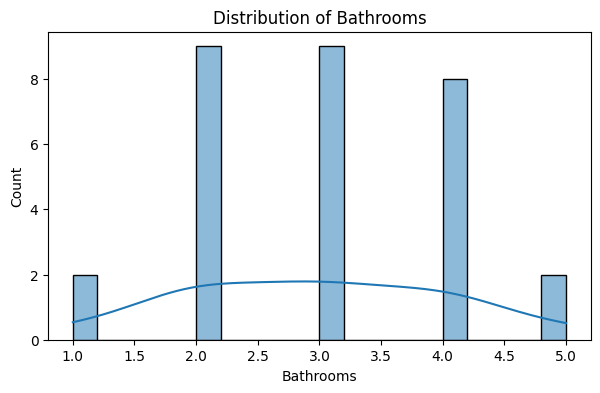

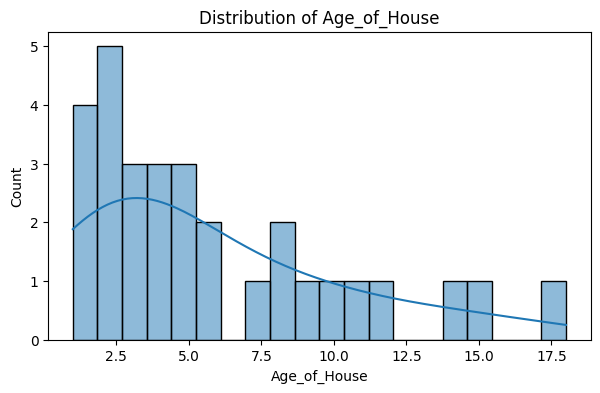

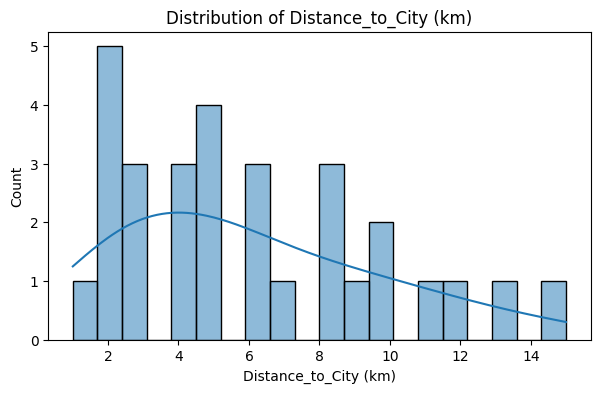

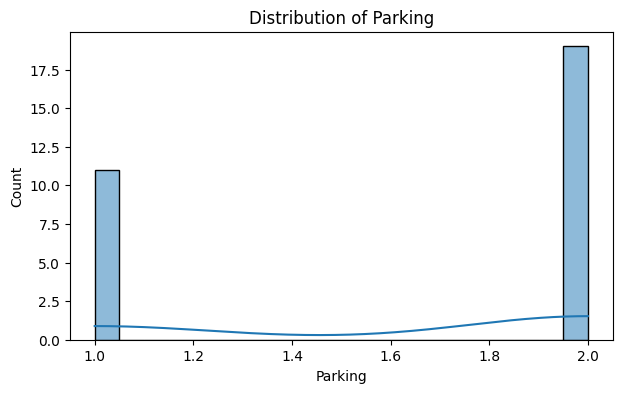

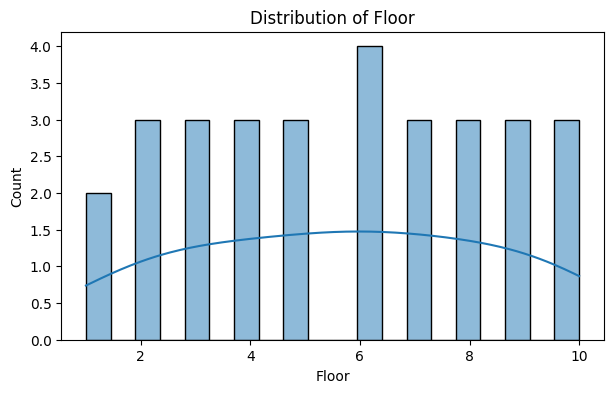

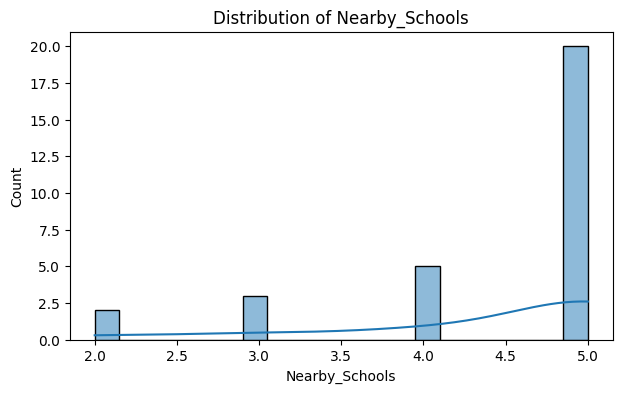

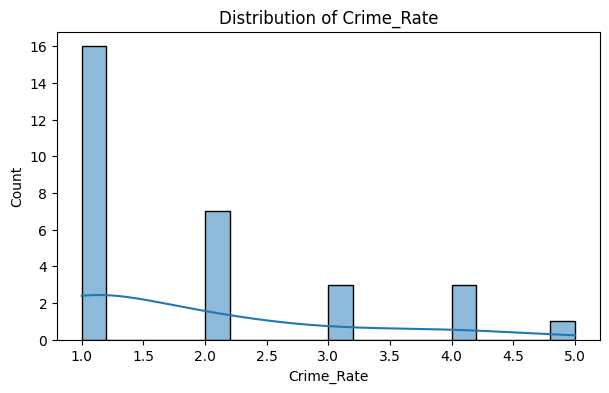

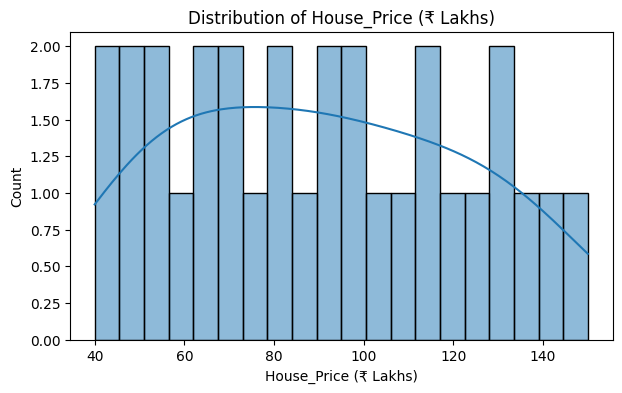

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(7,4))

    sns.histplot(df[col], bins=20, kde=True)

    plt.title(f'Distribution of {col}')
    plt.show()

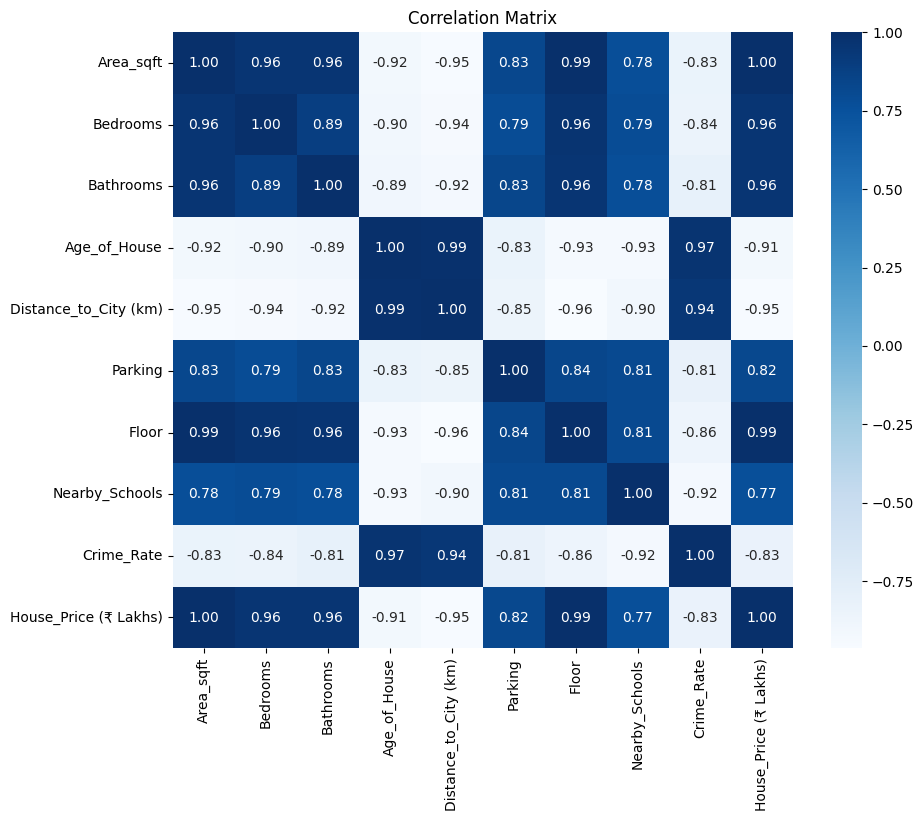

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='Blues',
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

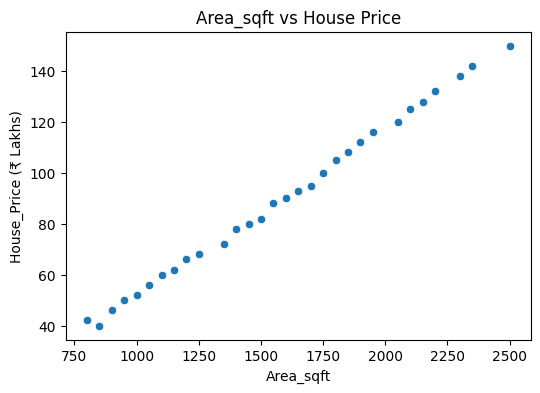

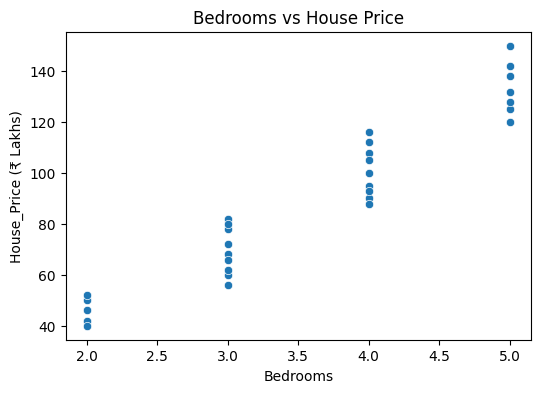

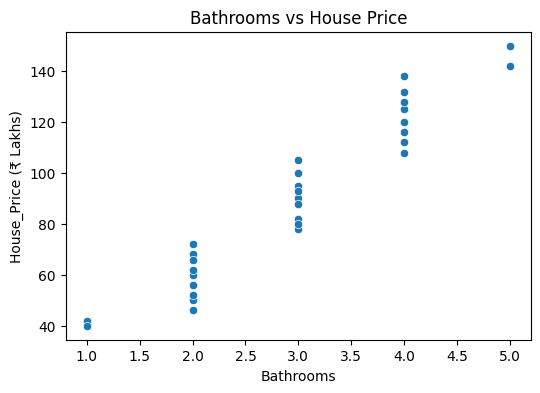

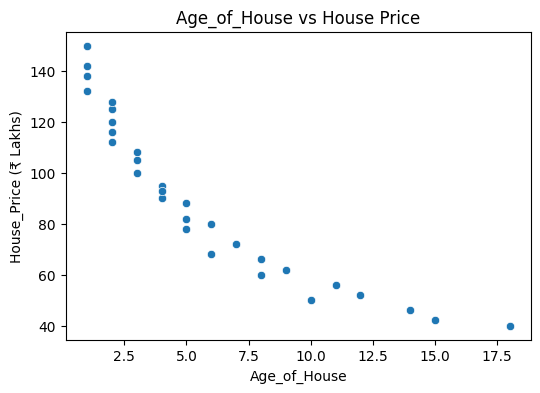

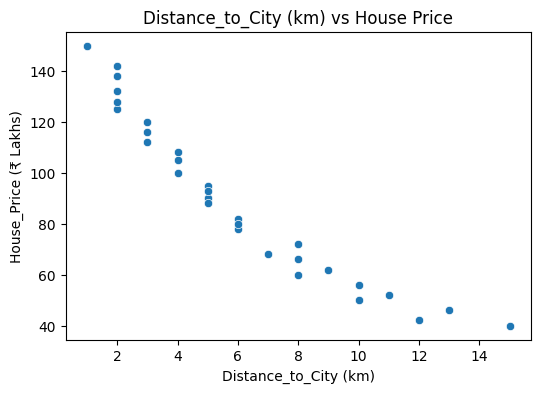

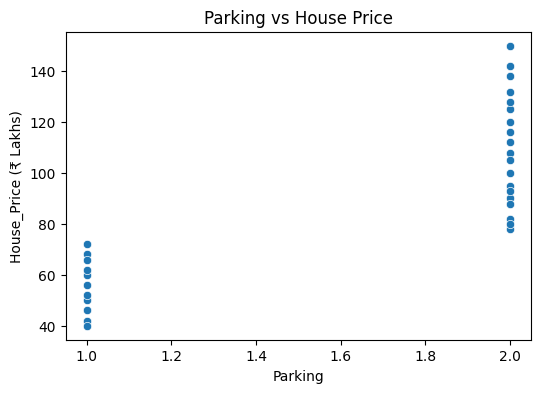

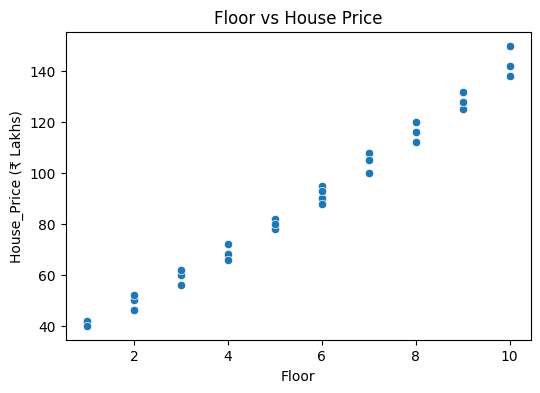

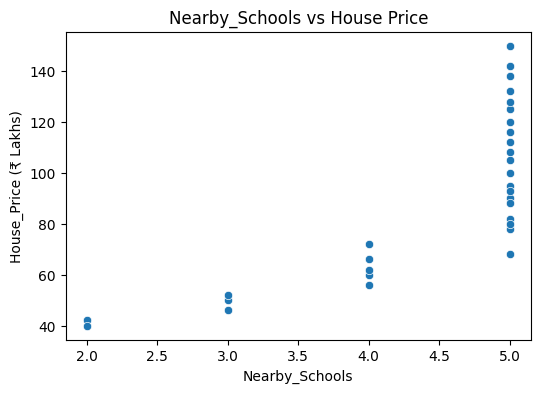

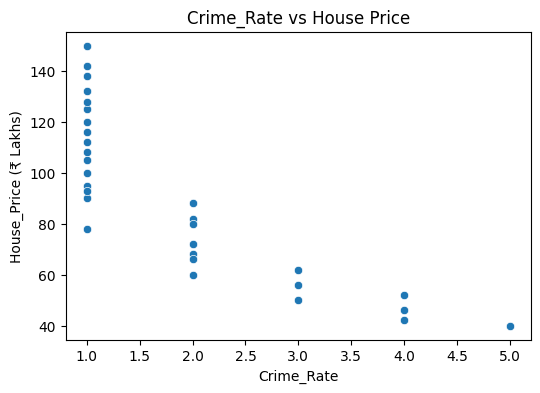

In [ ]:
features = df.drop('House_Price (₹ Lakhs)', axis=1).columns

for col in features:
    plt.figure(figsize=(6,4))

    sns.scatterplot(
        data=df,
        x=col,
        y='House_Price (₹ Lakhs)'
    )

    plt.title(f'{col} vs House Price')

    plt.show()

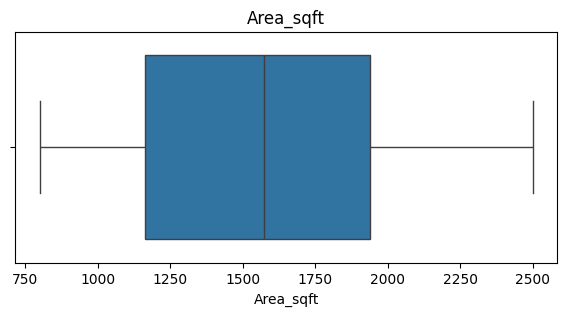

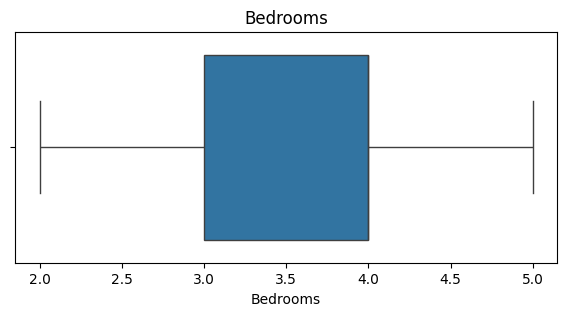

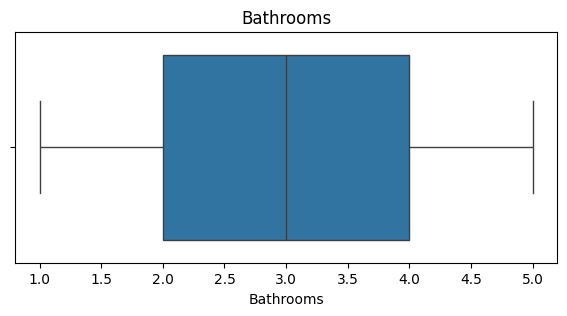

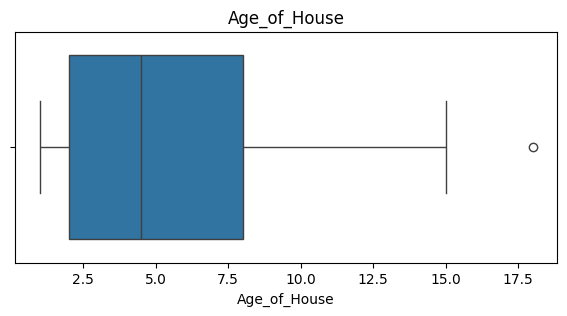

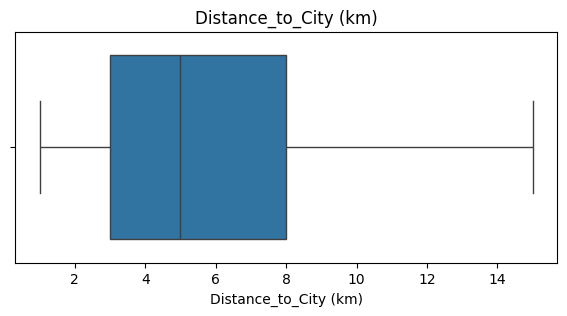

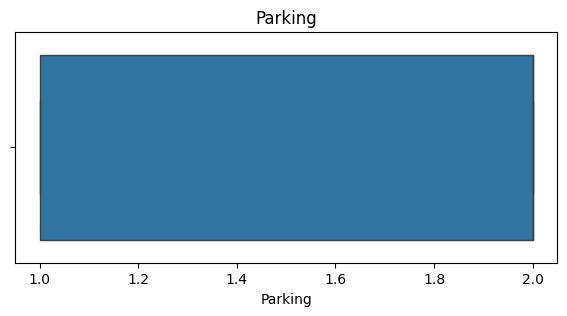

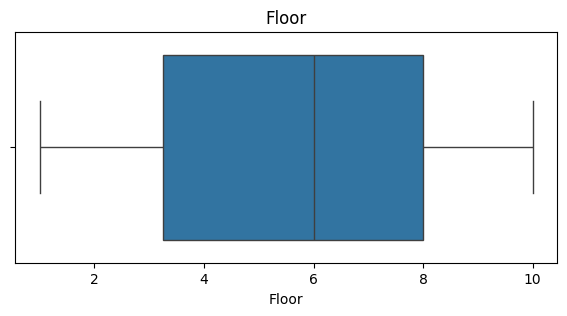

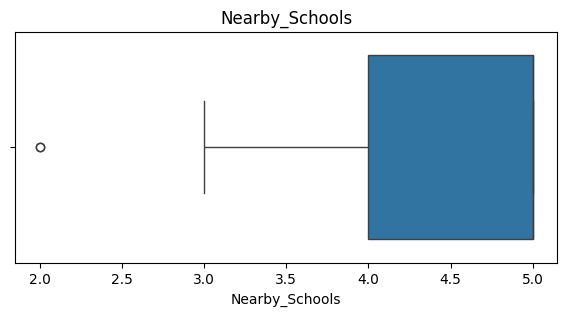

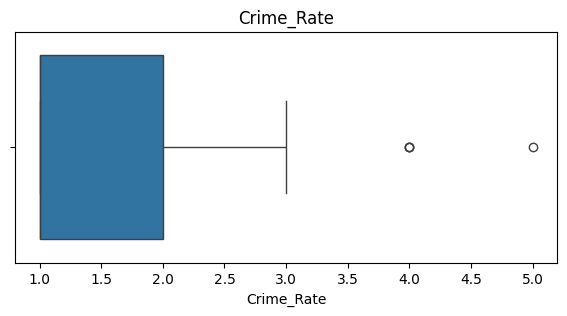

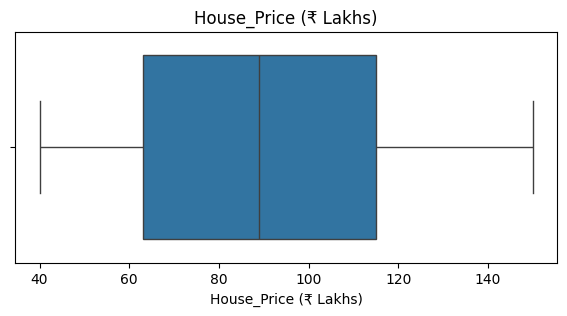

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(7,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [ ]:
X = df.drop('House_Price (₹ Lakhs)', axis=1)
y = df['House_Price (₹ Lakhs)']

In [ ]:
scaler = StandardScaler()

# Feature Engineering

No additional features were created for this dataset. After analyzing the dataset and feature relationships during EDA, all existing features were found to be relevant for predicting house prices. The original features were retained for model training.

Feature scaling was performed later on the training data to prepare the numerical features for regression modeling while preventing data leakage.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
linear_pred = linear_model.predict(X_test_scaled)

In [ ]:
print("Linear Regression Performance")
print("-" * 35)

print("MAE :", mean_absolute_error(y_test, linear_pred))
print("MSE :", mean_squared_error(y_test, linear_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, linear_pred)))
print("R² Score:", r2_score(y_test, linear_pred))

Linear Regression Performance
-----------------------------------
MAE : 0.7242622762168196
MSE : 0.5987720884011843
RMSE: 0.7738036497724629
R² Score: 0.9987989862278559


In [ ]:
decision_model = DecisionTreeRegressor()
decision_model.fit(X_train_scaled, y_train)

DecisionTreeRegressor()

In [ ]:
decision_pred = decision_model.predict(X_test_scaled)

In [ ]:
print("Decision Tree Regressor Performance")
print("-" * 35)

print("MAE :", mean_absolute_error(y_test, decision_pred))
print("MSE :", mean_squared_error(y_test, decision_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, decision_pred)))
print("R² Score:", r2_score(y_test, decision_pred))

Decision Tree Regressor Performance
-----------------------------------
MAE : 5.166666666666667
MSE : 40.166666666666664
RMSE: 6.3377177806105145
R² Score: 0.9194339202139514


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "MAE": [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, decision_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, decision_pred))
    ],
    "R² Score": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, decision_pred)
    ]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,0.724262,0.773804,0.998799
1,Decision Tree,5.166667,6.337718,0.919434


In [ ]:
sample = X_test.iloc[[0]]

linear_prediction = linear_model.predict(
    scaler.transform(sample)
)

decision_prediction = decision_model.predict(sample)

print("Actual House Price :", y_test.iloc[0])

print("Linear Regression Prediction :", round(linear_prediction[0], 2))

print("Decision Tree Prediction :", round(decision_prediction[0], 2))

Actual House Price : 142
Linear Regression Prediction : 141.46
Decision Tree Prediction : 150.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
